In [14]:
import pandas as pd 
import numpy as np
from phik import phik_matrix
import matplotlib.pyplot as plt

In [15]:
loan_df = pd.read_csv(r"C:\Users\David gathara marigi\Downloads\loan_data.csv", parse_dates=['DATE_OF_BIRTH', 'DISBURSAL_DATE'], infer_datetime_format=True) 

C:\Users\David gathara marigi\AppData\Local\Temp\ipykernel_15824\3732910638.py:1: FutureWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  loan_df = pd.read_csv(r"C:\Users\David gathara marigi\Downloads\loan_data.csv", parse_dates=['DATE_OF_BIRTH', 'DISBURSAL_DATE'], infer_datetime_format=True)
C:\Users\David gathara marigi\AppData\Local\Temp\ipykernel_15824\3732910638.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  loan_df = pd.read_csv(r"C:\Users\David gathara marigi\Downloads\loan_data.csv", parse_dates=['DATE_OF_BIRTH', 'DISBURSAL_DATE'], infer_datetime_format=True)
C:\Users\David gathara marigi\AppData\Local\Temp\ipykernel_15824\3732910638.py:1: UserWarnin

In [16]:
loan_df.drop('UNIQUEID', axis=1, inplace=True)

In [17]:
for col in loan_df.columns: 
    fraction_unique = loan_df[col].unique().shape[0] / loan_df.shape[0] 
if fraction_unique > 0.5: 
        print(col)

In [18]:
drop_cols = ['MOBILENO_AVL_FLAG']

In [19]:
pri_sec_cols = [c for c in loan_df.columns if c[:3] in ['PRI', 'SEC'] and c not in ['PRI_NO_ACCTS', 'PRI_OVERDUE_ACCTS']] 
drop_cols.extend(pri_sec_cols) 
loan_df.drop(columns=drop_cols, axis=1, inplace=True)

<Axes: >

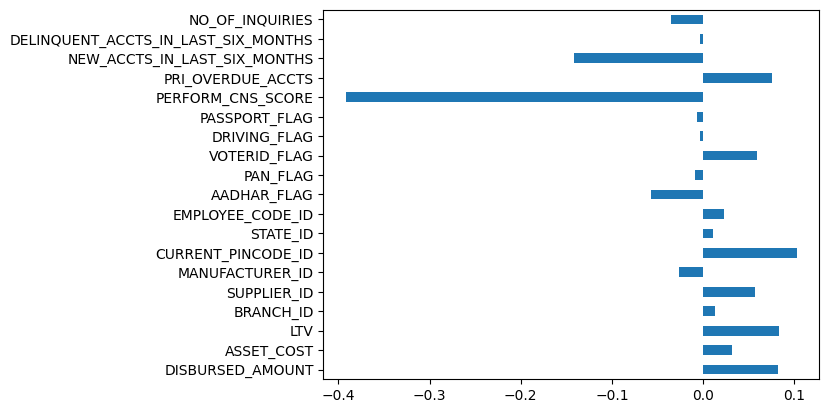

In [20]:
loan_df.select_dtypes(include=[np.number]).corr().loc['LOAN_DEFAULT'][:-1].plot.barh()

In [21]:
from scipy.stats import pearsonr 
from pandas.api.types import is_numeric_dtype 

In [22]:
for c in loan_df.columns[:-1]: 
    if is_numeric_dtype(loan_df[c]):
        correlation, pvalue = pearsonr(loan_df[c], loan_df['LOAN_DEFAULT']) 
        print(f'{c : <40}: {correlation : .4f}, significant: {pvalue <= 0.05}')

DISBURSED_AMOUNT                        :  0.0827, significant: True
ASSET_COST                              :  0.0322, significant: True
LTV                                     :  0.0834, significant: True
BRANCH_ID                               :  0.0129, significant: True
SUPPLIER_ID                             :  0.0572, significant: True
MANUFACTURER_ID                         : -0.0262, significant: True
CURRENT_PINCODE_ID                      :  0.1029, significant: True
STATE_ID                                :  0.0115, significant: True
EMPLOYEE_CODE_ID                        :  0.0235, significant: True
AADHAR_FLAG                             : -0.0565, significant: True
PAN_FLAG                                : -0.0083, significant: True
VOTERID_FLAG                            :  0.0592, significant: True
DRIVING_FLAG                            : -0.0035, significant: False
PASSPORT_FLAG                           : -0.0068, significant: True
PERFORM_CNS_SCORE                

In [23]:
loan_df.drop(columns=['DRIVING_FLAG', 'DELINQUENT_ACCTS_IN_LAST_SIX_MONTHS'], axis=1, inplace=True)

In [24]:
loan_df_epoch_time = loan_df.copy() 
loan_df_epoch_time['DATE_OF_BIRTH'] = (loan_df_epoch_time['DATE_OF_BIRTH'] - pd.to_datetime('1-1-1970')).dt.total_seconds() 
loan_df_epoch_time['DISBURSAL_DATE'] = (loan_df_epoch_time['DISBURSAL_DATE'] - pd.to_datetime('1-1-1970')).dt.total_seconds() 
sample = loan_df_epoch_time.sample(30, random_state=1)

In [25]:
interval_columns = ['DISBURSED_AMOUNT', 'ASSET_COST', 'LTV', 'DATE_OF_BIRTH', 'DISBURSAL_DATE', 'PERFORM_CNS_SCORE', 'NEW_ACCTS_IN_LAST_SIX_MONTHS', 'NO_OF_INQUIRIES'] 
sample.phik_matrix(interval_cols=interval_columns)

c:\Users\David gathara marigi\AppData\Local\Programs\Python\Python312\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable PASSPORT_FLAG for analysis 1. Dropping this column
  warnings.warn(


,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,...,PAN_FLAG,VOTERID_FLAG,PERFORM_CNS_SCORE,PERFORM_CNS_SCORE_DESCRIPTION,PRI_OVERDUE_ACCTS,NEW_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
DISBURSED_AMOUNT,1.000000,0.802997,0.000000,0.705767,1.0,0.337831,1.000000,0.000000,0.098943,0.411112,...,0.000000,0.371968,0.000000,0.000000,0.479029,0.000000,0.000000,0.000000,0.000000,0.195377
ASSET_COST,0.802997,1.000000,0.000000,0.908517,1.0,0.520826,1.000000,0.000000,0.605987,0.721756,...,0.244285,0.000000,0.754998,0.781434,0.945093,0.000000,0.709320,0.800105,0.000000,0.266155
LTV,0.000000,0.000000,1.000000,0.521573,1.0,0.541603,0.940088,0.686791,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.435301,0.614656,0.395580,0.466423,0.000000
BRANCH_ID,0.705767,0.908517,0.521573,1.000000,1.0,0.000000,1.000000,0.459095,0.720957,0.804631,...,0.000000,0.000000,0.850592,0.699454,1.000000,0.901389,0.862056,0.834014,0.573864,0.702217
SUPPLIER_ID,1.000000,1.000000,1.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
MANUFACTURER_ID,0.337831,0.520826,0.541603,0.000000,1.0,1.000000,1.000000,0.240612,0.000000,0.695770,...,0.000000,0.000000,0.000000,0.000000,0.667772,0.472302,0.500424,0.479626,0.433809,0.000000
CURRENT_PINCODE_ID,1.000000,1.000000,0.940088,1.000000,1.0,1.000000,1.000000,0.876953,1.000000,0.948528,...,1.000000,0.000000,0.948170,0.953868,1.000000,1.000000,0.981499,0.967334,1.000000,0.000000
DATE_OF_BIRTH,0.000000,0.000000,0.686791,0.459095,1.0,0.240612,0.876953,1.000000,0.325120,0.511990,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.634612,0.122969
EMPLOYMENT_TYPE,0.098943,0.605987,0.000000,0.720957,1.0,0.000000,1.000000,0.325120,1.000000,0.000000,...,0.000000,0.000000,0.360244,0.265010,0.000000,0.069906,0.000000,0.512636,0.000000,0.760402
DISBURSAL_DATE,0.411112,0.721756,0.000000,0.804631,1.0,0.695770,0.948528,0.511990,0.000000,1.000000,...,0.244285,0.000000,0.560729,0.700571,0.898221,0.000000,0.793864,0.907767,0.522707,0.000000


In [26]:
sample.significance_matrix(interval_cols=interval_columns)

c:\Users\David gathara marigi\AppData\Local\Programs\Python\Python312\Lib\site-packages\phik\data_quality.py:82: UserWarning: Not enough unique value for variable PASSPORT_FLAG for analysis 1. Dropping this column
  warnings.warn(


,DISBURSED_AMOUNT,ASSET_COST,LTV,BRANCH_ID,SUPPLIER_ID,MANUFACTURER_ID,CURRENT_PINCODE_ID,DATE_OF_BIRTH,EMPLOYMENT_TYPE,DISBURSAL_DATE,...,PAN_FLAG,VOTERID_FLAG,PERFORM_CNS_SCORE,PERFORM_CNS_SCORE_DESCRIPTION,PRI_OVERDUE_ACCTS,NEW_ACCTS_IN_LAST_SIX_MONTHS,AVERAGE_ACCT_AGE,CREDIT_HISTORY_LENGTH,NO_OF_INQUIRIES,LOAN_DEFAULT
DISBURSED_AMOUNT,5.871332,2.403599,0.873876,2.657936,2.510064,1.223359,2.630012,0.920990,0.570993,1.514794,...,0.420079,0.824931,0.585582,0.820321,0.642648,0.343632,1.132237,1.438623,0.336196,0.804972
ASSET_COST,2.403599,5.828986,0.867963,2.598409,2.518454,1.151747,2.615772,0.201331,2.109777,1.327076,...,0.878362,-0.180349,2.062735,2.171671,1.607886,0.364796,2.050034,2.344535,1.012509,0.991345
LTV,0.873876,0.867963,6.057886,1.847685,2.499876,1.517873,2.419421,2.036008,0.176102,0.721171,...,0.275928,-0.828093,0.951504,1.492310,0.617945,1.538369,1.916682,2.130319,1.400359,-0.100693
BRANCH_ID,2.657936,2.598409,1.847685,4.074390,3.159191,1.573280,3.255942,1.892804,2.378859,2.160401,...,-0.013381,-0.226856,1.989692,2.253293,1.730302,1.670218,2.467705,2.644898,1.813968,2.247243
SUPPLIER_ID,2.510064,2.518454,2.499876,3.159191,3.508364,2.350526,3.482670,2.540065,2.878159,2.533118,...,1.273238,1.563938,2.366169,2.590638,1.477090,1.775372,2.842148,2.887451,1.671598,2.529058
MANUFACTURER_ID,1.223359,1.151747,1.517873,1.573280,2.350526,6.358685,2.399309,0.681904,-0.244766,1.245732,...,0.601114,-0.068429,0.694403,0.389919,1.129411,0.728005,1.468740,1.473950,1.197886,-1.107275
CURRENT_PINCODE_ID,2.630012,2.615772,2.419421,3.255942,3.482670,2.399309,3.550882,2.469581,2.903742,2.442270,...,1.230581,1.241275,2.301979,2.523615,1.435619,1.877167,2.728535,2.912480,1.722122,2.253932
DATE_OF_BIRTH,0.920990,0.201331,2.036008,1.892804,2.540065,0.681904,2.469581,5.169322,0.639878,1.702587,...,0.464716,-0.378032,0.301617,0.954007,0.399577,0.476457,1.132315,1.443278,1.186869,0.340017
EMPLOYMENT_TYPE,0.570993,2.109777,0.176102,2.378859,2.878159,-0.244766,2.903742,0.639878,5.515617,-0.088438,...,1.237034,-0.194893,1.171523,0.951656,0.091056,0.814567,0.810910,1.748933,0.523552,3.387351
DISBURSAL_DATE,1.514794,1.327076,0.721171,2.160401,2.533118,1.245732,2.442270,1.702587,-0.088438,5.612587,...,0.835921,0.428880,1.755194,2.344555,1.779567,-0.362426,2.232610,2.475993,1.171751,0.094668


In [28]:
for c in loan_df_epoch_time.columns: 
    if c not in interval_columns: 
        loan_df_epoch_time[c] = loan_df_epoch_time[c].astype('category')

In [30]:
import phik

In [31]:
phik_correlations = [] 
phik_significances = [] 
columns = loan_df_epoch_time.columns 
y = loan_df_epoch_time['LOAN_DEFAULT'] 
for c in columns: 
    x = loan_df_epoch_time[c] 
if c in interval_columns: 
        phik_correlations.append(phik.phik_from_array(x, y, 
[c])) 
        phik_significances.append( 
            phik.significance.significance_from_array(x, y, 
[c])[0]) 
else: 
    phik_correlations.append(phik.phik_from_array(x, y)) 
    phik_significances.append(phik.significance.significance_from_array(x, y)
 [0])

In [32]:
from sklearn.metrics import normalized_mutual_info_score

In [34]:
# Convert categorical columns to numerical codes
loan_df_encoded = loan_df.apply(lambda x: pd.factorize(x)[0])

# Now compute correlation matrix
corr_matrix = loan_df_encoded.corr(method=normalized_mutual_info_score)

In [35]:
from sklearn.feature_selection import mutual_info_classif

In [36]:
numeric_features = loan_df.select_dtypes(include=['number']).copy() 
numeric_features.drop('LOAN_DEFAULT', axis=1, inplace=True) 
list(zip(numeric_features.columns, mutual_info_classif(numeric_features,loan_df['LOAN_DEFAULT'])))

[('DISBURSED_AMOUNT', 0.010176550199999523),
 ('ASSET_COST', 0.006181461880762518),
 ('LTV', 0.009184812877329751),
 ('BRANCH_ID', 0.012962778005450204),
 ('SUPPLIER_ID', 0.025070116221571404),
 ('MANUFACTURER_ID', 0.0048248553913143866),
 ('CURRENT_PINCODE_ID', 0.0209611160044072),
 ('STATE_ID', 0.005998634892481425),
 ('EMPLOYEE_CODE_ID', 0.02723222689614868),
 ('AADHAR_FLAG', 0.017887999267543142),
 ('PAN_FLAG', 0.0),
 ('VOTERID_FLAG', 0.0003514270968452138),
 ('PASSPORT_FLAG', 0.00023335698635262858),
 ('PERFORM_CNS_SCORE', 0.11201683086137426),
 ('PRI_OVERDUE_ACCTS', 0.0006141837320856602),
 ('NEW_ACCTS_IN_LAST_SIX_MONTHS', 0.01799663619890346),
 ('NO_OF_INQUIRIES', 0.001415898628202017)]

In [37]:
from sklearn.feature_selection import chi2 
chi2(loan_df[['PAN_FLAG', 'STATE_ID']], loan_df['LOAN_DEFAULT'])

(array([ 8.46807323, 48.3495596 ]), array([3.61434074e-03, 3.56624293e-12]))

In [38]:
from sklearn.feature_selection import f_classif

In [39]:
f_classif(loan_df[['PERFORM_CNS_SCORE', 'PAN_FLAG', 'STATE_ID']], loan_df['LOAN_DEFAULT'])

(array([2.41525739e+04, 9.15861992e+00, 1.74974209e+01]),
 array([0.00000000e+00, 2.47596457e-03, 2.87881660e-05]))

In [40]:
from sklearn.feature_selection import SelectKBest 
k_best = SelectKBest(f_classif, k=5).fit_transform(loan_df_epoch_time[interval_columns], loan_df_epoch_time['LOAN_DEFAULT'] 
)

In [ ]:
#feature engineering

In [41]:
import re

In [42]:
re.search(r'(\d+)yrs\s+(\d+)mon', '1yrs 11mon').groups()

('1', '11')

In [43]:
def convert_date_spans(date_str): 
#Parses date spans of the form "1yrs 1mon" into the number of months as an integer.
    yrs, mon = re.search(r'(\d+)yrs\s+(\d+)mon', 
date_str).groups() 
    yrs, mon = int(yrs), int(mon) 
    months = yrs * 12 + mon 
    return months

In [44]:
import swifter

In [45]:
loan_df['AVERAGE_ACCT_AGE_MONTHS'] = loan_df.swifter.apply(lambda x: convert_date_spans(x['AVERAGE_ACCT_AGE']), axis=1) 
loan_df['CREDIT_HISTORY_LENGTH_MONTHS'] = loan_df.swifter.apply(lambda x: convert_date_spans(x['CREDIT_HISTORY_LENGTH']), axis=1) 
loan_df.drop(['AVERAGE_ACCT_AGE', 'CREDIT_HISTORY_LENGTH'], axis=1, inplace=True)

Pandas Apply:   0%|          | 0/133154 [00:00<?, ?it/s]

Pandas Apply:   0%|          | 0/133154 [00:00<?, ?it/s]

In [46]:
import seaborn as sns

<Axes: >

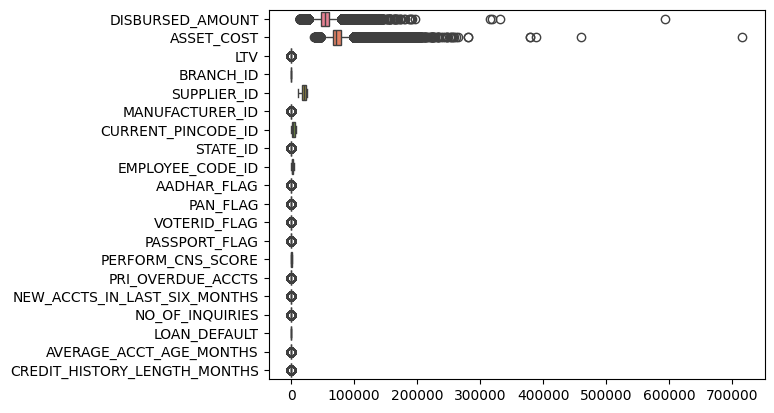

In [47]:
sns.boxplot(data=loan_df, orient='h')

<Axes: >

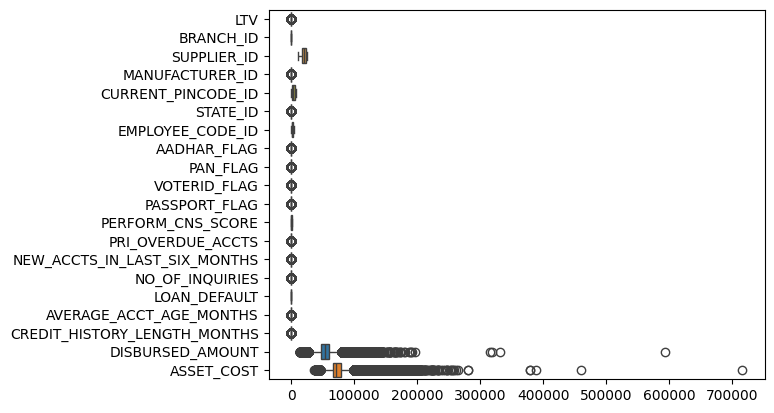

In [48]:
sns.boxplot(data=loan_df.drop(['DISBURSED_AMOUNT', 'ASSET_COST'], axis=1), orient='h') 
sns.boxplot(data=loan_df[['DISBURSED_AMOUNT', 'ASSET_COST']], orient='h')

<Axes: ylabel='Frequency'>

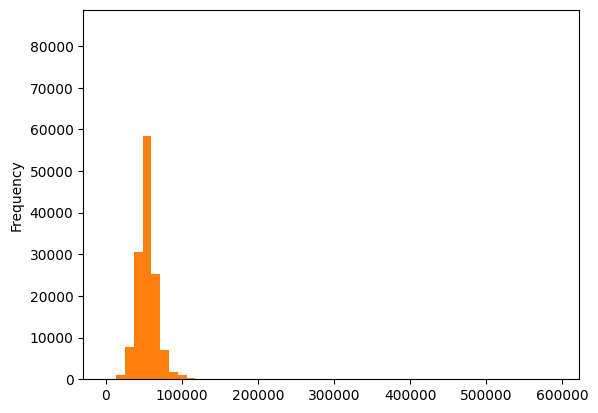

In [49]:
loan_df['AVERAGE_ACCT_AGE_MONTHS'].plot.hist(bins=30) 
loan_df['DISBURSED_AMOUNT'].plot.hist(bins=50)

In [50]:
import numpy as np

In [51]:
q3 = loan_df['DISBURSED_AMOUNT'].quantile(0.75) 
q1 = loan_df['DISBURSED_AMOUNT'].quantile(0.25) 
iqr = (q3 - q1) 
outliers = np.where(loan_df['DISBURSED_AMOUNT'] > (q3 + 1.5 * iqr))[0] 
print(1.5 * iqr + q3)

80400.0


In [52]:
loan_df['DISBURSED_AMOUNT'].clip(upper=1.5 * iqr + q3, inplace=True)

In [53]:
loan_df['AGE'] = (loan_df['DISBURSAL_DATE'] - loan_df['DATE_OF_BIRTH']) // 365

In [54]:
(loan_df['DISBURSAL_DATE'] - loan_df['DATE_OF_BIRTH']).dt.days

0         13463
1         15634
2          9702
3          7917
4         14124
          ...  
133149    14085
133150     8144
133151    10521
133152    12152
133153    16312
Length: 133154, dtype: int64

In [55]:
from dateutil import relativedelta

In [56]:
def calculate_age_in_years(x):
    return relativedelta.relativedelta(x['DISBURSAL_DATE'], x['DATE_OF_BIRTH']).years 
loan_df['AGE'] = loan_df.swifter.apply( 
lambda x: calculate_age_in_years(x), axis=1)

Pandas Apply:   0%|          | 0/133154 [00:00<?, ?it/s]

In [57]:
from sklearn.preprocessing import StandardScaler 
import matplotlib.pyplot as plt

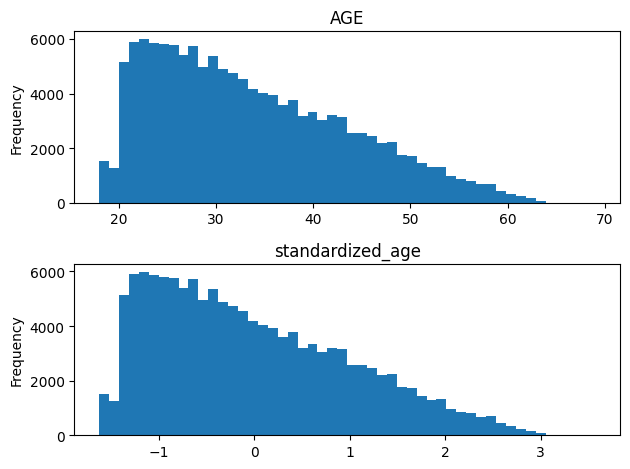

In [58]:
scaler = StandardScaler() 
loan_df['standardized_age'] = scaler.fit_transform(loan_df['AGE'].values.reshape(-1, 1)) 
f, ax = plt.subplots(2, 1) 
loan_df['AGE'].plot.hist(ax=ax[0], title='AGE', bins=50) 
loan_df['standardized_age'].plot.hist(ax=ax[1], title='standardized_age', bins=50) 
plt.tight_layout()

In [59]:
from  sklearn.preprocessing import PowerTransformer

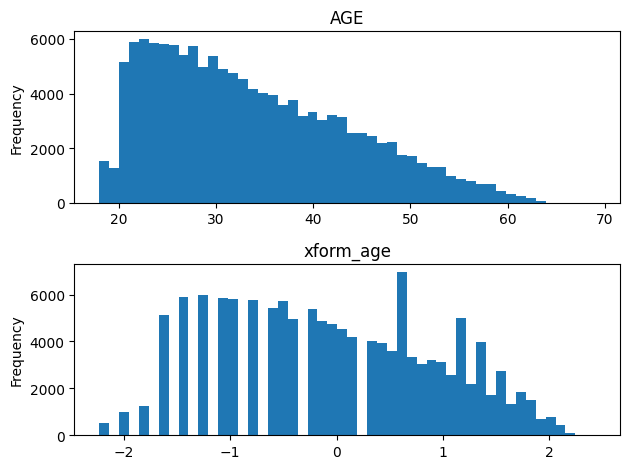

In [60]:
pt = PowerTransformer() 
loan_df['xform_age'] = pt.fit_transform(loan_df['AGE'].values.reshape(-1, 1)) 
f, ax = plt.subplots(2, 1) 
loan_df['AGE'].plot.hist(ax=ax[0], title='AGE', bins=50) 
loan_df['xform_age'].plot.hist(ax=ax[1], title='xform_age', bins=50) 
plt.tight_layout()

In [61]:
pt.transform(loan_df['AGE'].values.reshape(-1, 1))

array([[ 0.3856874 ],
       [ 0.90523825],
       [-0.78502857],
       ...,
       [-0.50945023],
       [ 0.08259266],
       [ 1.05772199]])

In [62]:
import pickle as pk

In [63]:
with open('age_pt.pk', 'wb') as f: 
    pk.dump(pt, f)

In [65]:
(loan_df['DISBURSAL_DATE'] - loan_df['DATE_OF_BIRTH']).dt.days

0         13463
1         15634
2          9702
3          7917
4         14124
          ...  
133149    14085
133150     8144
133151    10521
133152    12152
133153    16312
Length: 133154, dtype: int64

In [66]:
loan_df['DISBURSAL_DATE'].dt.dayofweek

0         1
1         6
2         3
3         2
4         2
         ..
133149    4
133150    4
133151    0
133152    2
133153    3
Name: DISBURSAL_DATE, Length: 133154, dtype: int32

In [67]:
from sklearn.preprocessing import KBinsDiscretizer

In [68]:
kbd = KBinsDiscretizer(n_bins=10, encode='ordinal') 
loan_df['binned_disbursed_amount'] = kbd.fit_transform( 
    loan_df['DISBURSED_AMOUNT'].values.reshape(-1, 1)).astype('int')

In [69]:
loan_df['EMPLOYMENT_TYPE'].fillna('Self employed', inplace=True) 
loan_df['EMPLOYMENT_TYPE'] = loan_df['EMPLOYMENT_TYPE'].map(lambda x: 1 if x == 'Self employed' else 0) 
loan_df['EMPLOYMENT_TYPE'] = loan_df['EMPLOYMENT_TYPE'].astype('int')

In [70]:
from sklearn.preprocessing import LabelEncoder

In [71]:
le = LabelEncoder() 
loan_df['le_branch_id'] = le.fit_transform(loan_df['BRANCH_ID'])

In [72]:
loan_df['MANUFACTURER_ID'].value_counts()

MANUFACTURER_ID
86     62507
45     32389
51     15395
48      9641
49      5831
120     5512
67      1416
145      450
153        9
152        4
Name: count, dtype: int64

Text(0.5, 0, 'MANUFACTURER_ID')

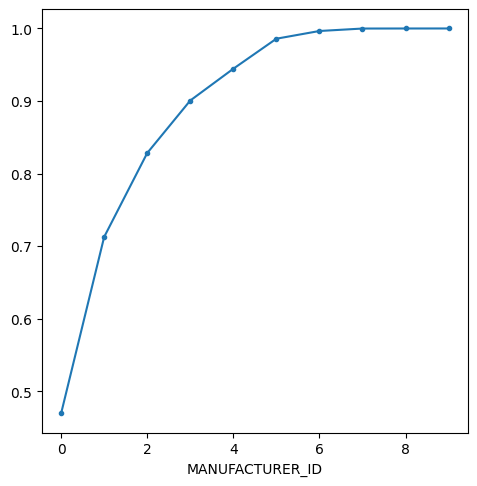

In [73]:
(loan_df['MANUFACTURER_ID'].value_counts().cumsum() / loan_df.shape[0]).reset_index(drop=True).plot(marker='.', figsize=(5.5, 5.5)) 
plt.xlabel('MANUFACTURER_ID')

([<matplotlib.axis.XTick at 0x1c38cd445f0>,
 [Text(0, 0, '86'),
  Text(1, 0, '45'),
  Text(2, 0, '51'),
  Text(3, 0, '48'),
  Text(4, 0, '49'),
  Text(5, 0, '120'),
  Text(6, 0, '67'),
  Text(7, 0, '145'),
  Text(8, 0, '153'),
  Text(9, 0, '152')])

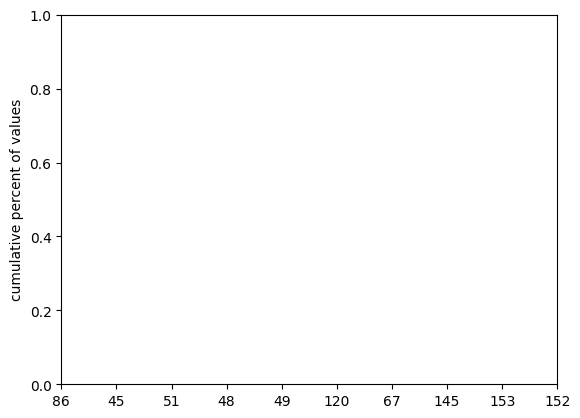

In [74]:
plt.ylabel('cumulative percent of values') 
plt.xticks(range(loan_df['MANUFACTURER_ID'].unique().shape[0]), loan_df['MANUFACTURER_ID'].value_counts().index)

In [75]:
loan_df.loc[~loan_df['MANUFACTURER_ID'].isin([86, 45, 51, 48, 49, 120]), 'MANUFACTURER_ID'] = 'other'

In [76]:
loan_df.loc[loan_df['MANUFACTURER_ID'].isin([67, 145, 153, 152]), 'MANUFACTURER_ID'] = 'other'

In [77]:
manufacturer_ohe = pd.get_dummies(loan_df['MANUFACTURER_ID'], prefix='MANU_ID', prefix_sep='=').drop(['MANU_ID=other'], axis=1)

In [78]:
loan_df_ohe = pd.concat([loan_df, manufacturer_ohe], axis=1)

In [ ]:
# dimensional reduction

In [79]:
from sklearn.decomposition import PCA

In [80]:
ss = StandardScaler() 
scaled = ss.fit_transform(loan_df_epoch_time[interval_columns])
pca = PCA(random_state=42) 
loan_pca = pca.fit_transform(scaled)

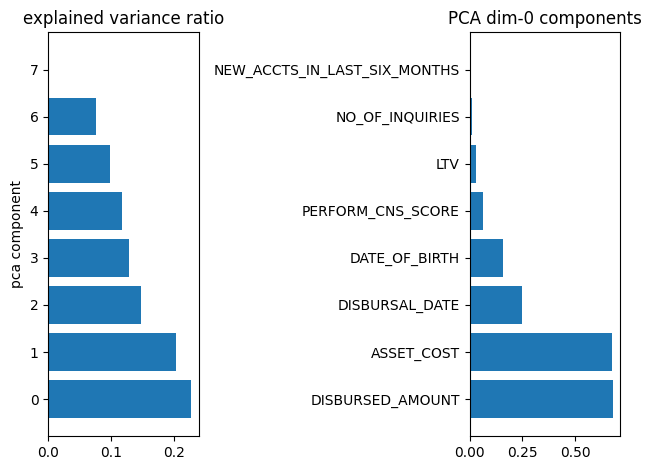

In [81]:
idx = pca.explained_variance_ratio_.argsort()[::-1] 
ticks = range(pca.n_components_) 
f, ax = plt.subplots(1, 2) 
ax[0].barh(ticks, pca.explained_variance_ratio_[idx]) 
ax[0].set_title('explained variance ratio') 
ax[0].set_ylabel('pca component') 
ax[0].set_yticks(ticks) 
comp_idx = abs(pca.components_[0]).argsort()[::-1] 
ax[1].barh(ticks, abs(pca.components_[0, comp_idx])) 
plt.yticks(ticks, np.array(interval_columns)[comp_idx]) 
ax[1].set_title('PCA dim-0 components') 
plt.tight_layout()